RUNS TEST

Code for Econometrics Project on the Weak form EMH. Using the Wald Walfowitz Runs test to test IID assumption. Tested with true IID and AR data.

In [6]:
import numpy as np
from statsmodels.sandbox.stats.runs import runstest_1samp
import pandas as pd


def iid_normal(T):
    return np.random.normal(0, 1, T)

n = 1000
T = 10000

sequences = []
for i in range(n):
    r = iid_normal(T)
    sequences.append(r)
    
data = np.array(sequences).T
df = pd.DataFrame(data)

sig_level = []
for col in df.columns: 
   df[col] = np.where(df[col] >= 0, 1, 0)
   z_stat, p_val = runstest_1samp(df[col])
   if p_val < 0.05:
       sig_level.append(1)
   else:
       sig_level.append(0)

print((sum(sig_level))/n)



0.057


1,000 sequences of length 10,000. Runs test on each sequence, rough type 1 error rate of 5%.

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.sandbox.stats.runs import runstest_1samp

n = 1000
T = 10000
rho = 0.01

noise = np.random.normal(0, 1, size=(T, n))

X = np.zeros((T, n))

for t in range(1, T):
    X[t, :] = rho * X[t - 1, :] + noise[t, :] 

df = pd.DataFrame(X) 

sig_level = []
for col in df.columns:
    df[col] = np.where(df[col] >= 0, 1, 0)
    z_stat, p_val = runstest_1samp(df[col])
    if p_val < 0.05:
       sig_level.append(1)
    else:
       sig_level.append(0)

print((sum(sig_level))/n)

0.0


It seems when we generate our autoregressive data, Runs Test good at identifying autocorrelation.

C:\Users\danie\AppData\Local\Temp\ipykernel_9516\2596208661.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


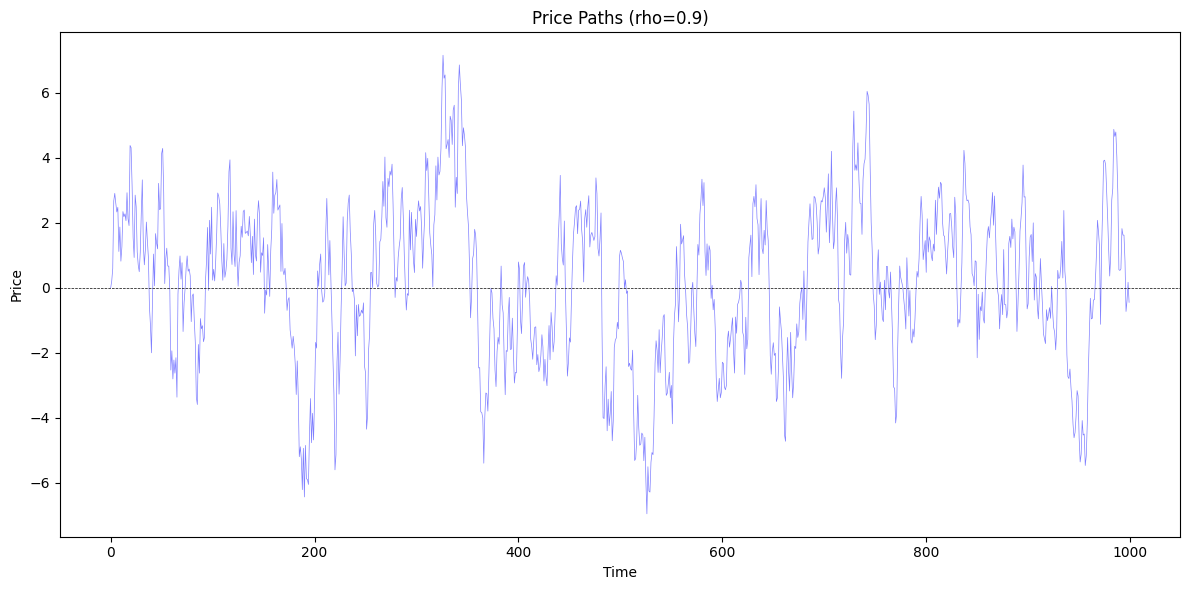

In [14]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.figure(figsize=(12, 6))
cmap = cm.get_cmap('tab10')
for i in range(1, 2):
  #  color = cmap(i % 10) 
    plt.plot(X[:1000, i], alpha=0.5, linewidth=0.5, color='blue')
plt.xlabel('Time')
plt.ylabel('Price')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f'Price Paths (rho={rho})')
plt.tight_layout()
plt.show()